In [1]:
import os, random
import numpy as np
import tensorflow as tf

SEED = 42  # choose any integer

os.environ["PYTHONHASHSEED"] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)


In [2]:
import pandas as pd
import numpy as np
import mne

In [3]:
import mne

fname = r"D:\EEG DATA\dataverse_files\s01.edf"  # full or relative path
raw = mne.io.read_raw_edf(fname, preload=True)
print(raw)
print(raw.info)          # metadata: channels, sfreq, etc.
data, times = raw.get_data(return_times=True)

Extracting EDF parameters from D:\EEG DATA\dataverse_files\s01.edf...
EDF file detected
Setting channel info structure...
Creating raw.info structure...
Reading 0 ... 211249  =      0.000 ...   844.996 secs...
<RawEDF | s01.edf, 19 x 211250 (845.0 s), ~30.6 MiB, data loaded>
<Info | 8 non-empty values
 bads: []
 ch_names: Fp2, F8, T4, T6, O2, Fp1, F7, T3, T5, O1, F4, C4, P4, F3, C3, ...
 chs: 19 EEG
 custom_ref_applied: False
 highpass: 0.0 Hz
 lowpass: 125.0 Hz
 meas_date: 2004-08-20 12:19:24 UTC
 nchan: 19
 projs: []
 sfreq: 250.0 Hz
 subject_info: <subject_info | his_id: OJS>
>


Using matplotlib as 2D backend.


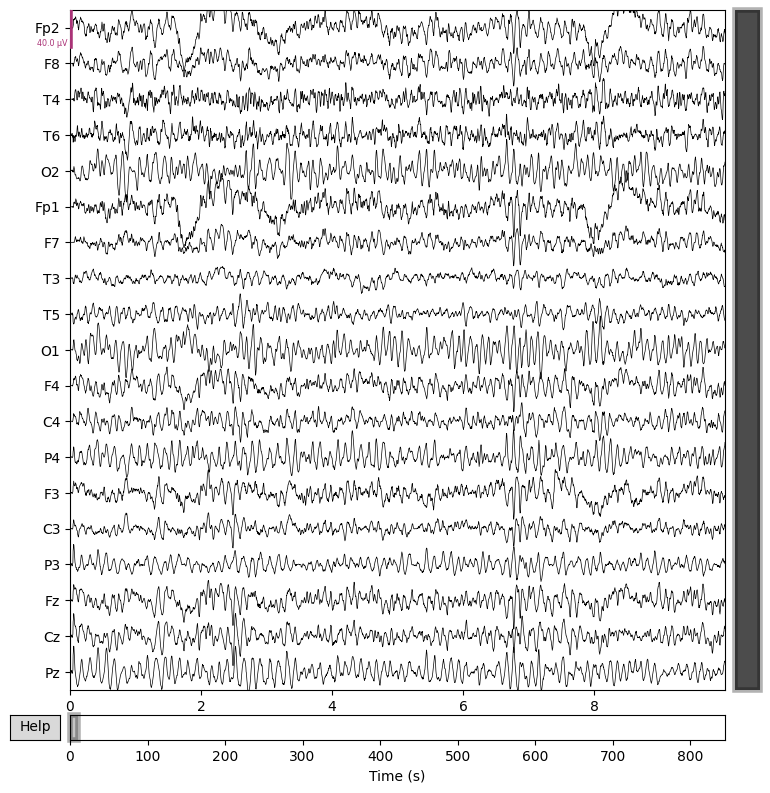

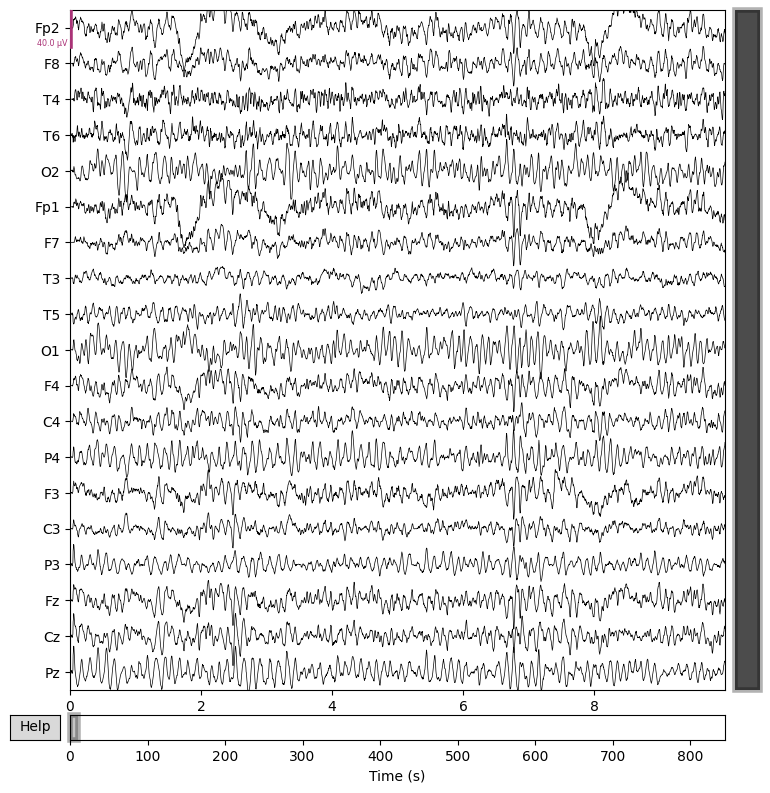

In [4]:
raw.plot()

Effective window size : 8.192 (s)


Plotting power spectral density (dB=True).


C:\Users\Manisha\AppData\Local\Temp\ipykernel_29972\4108630121.py:1: RuntimeWarning: Channel locations not available. Disabling spatial colors.
  raw.compute_psd().plot()
f:\Anaconda\envs\new_env\Lib\site-packages\mne\viz\utils.py:158: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  (fig or plt).show(**kwargs)


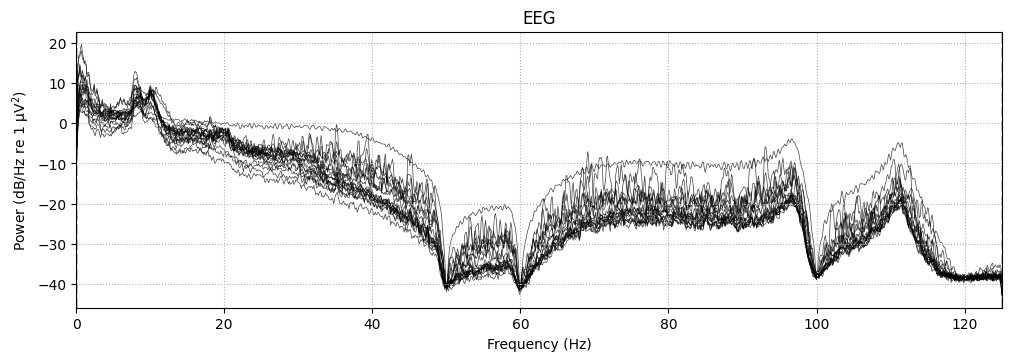

In [5]:
raw.compute_psd().plot()

Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 0.5 - 40 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 0.50
- Lower transition bandwidth: 0.50 Hz (-6 dB cutoff frequency: 0.25 Hz)
- Upper passband edge: 40.00 Hz
- Upper transition bandwidth: 10.00 Hz (-6 dB cutoff frequency: 45.00 Hz)
- Filter length: 1651 samples (6.604 s)

Effective window size : 8.192 (s)
Plotting power spectral density (dB=True).


C:\Users\Manisha\AppData\Local\Temp\ipykernel_29972\524655454.py:1: RuntimeWarning: Channel locations not available. Disabling spatial colors.
  raw.filter(0.5, 40); raw.compute_psd().plot()
f:\Anaconda\envs\new_env\Lib\site-packages\mne\viz\utils.py:158: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  (fig or plt).show(**kwargs)


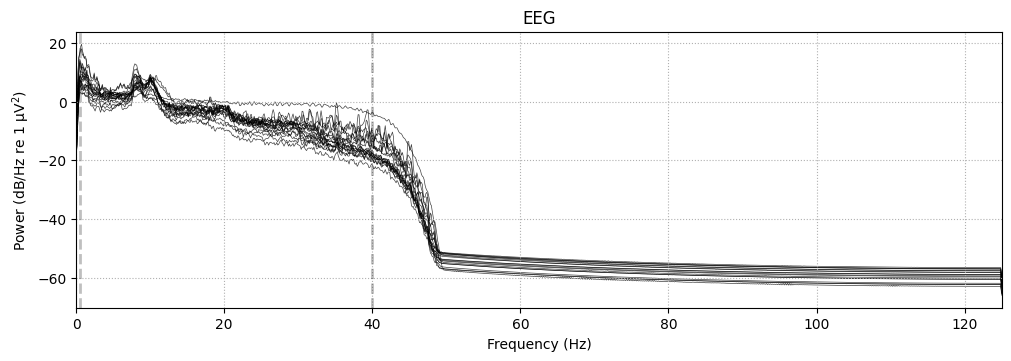

In [6]:
raw.filter(0.5, 40); raw.compute_psd().plot()

In [7]:
from mne import make_fixed_length_epochs

epochs = make_fixed_length_epochs(raw, duration=1, overlap=0)                    
print(epochs.info)
print(len(epochs.events))

Not setting metadata
845 matching events found
No baseline correction applied
0 projection items activated
<Info | 8 non-empty values
 bads: []
 ch_names: Fp2, F8, T4, T6, O2, Fp1, F7, T3, T5, O1, F4, C4, P4, F3, C3, ...
 chs: 19 EEG
 custom_ref_applied: False
 highpass: 0.5 Hz
 lowpass: 40.0 Hz
 meas_date: 2004-08-20 12:19:24 UTC
 nchan: 19
 projs: []
 sfreq: 250.0 Hz
 subject_info: <subject_info | his_id: OJS>
>
845


Using data from preloaded Raw for 845 events and 250 original time points ...
0 bad epochs dropped
Using data from preloaded Raw for 20 events and 250 original time points ...


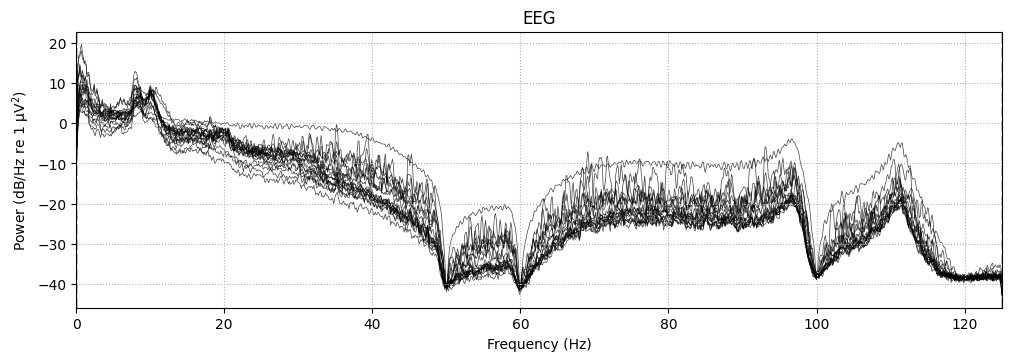

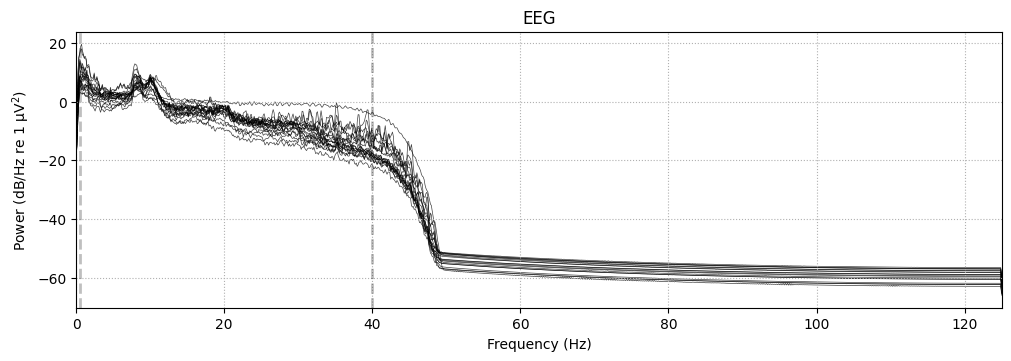

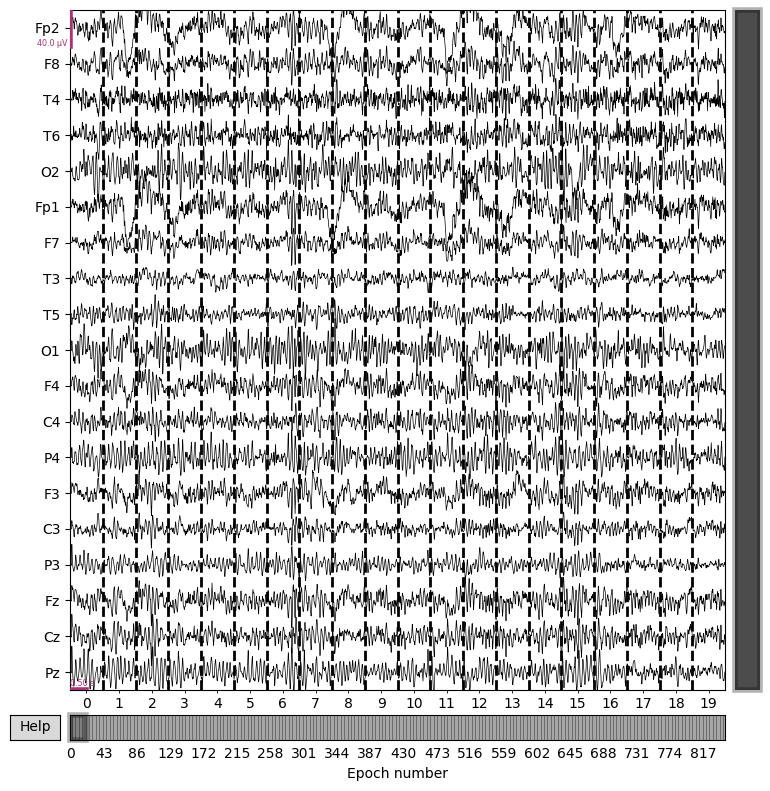

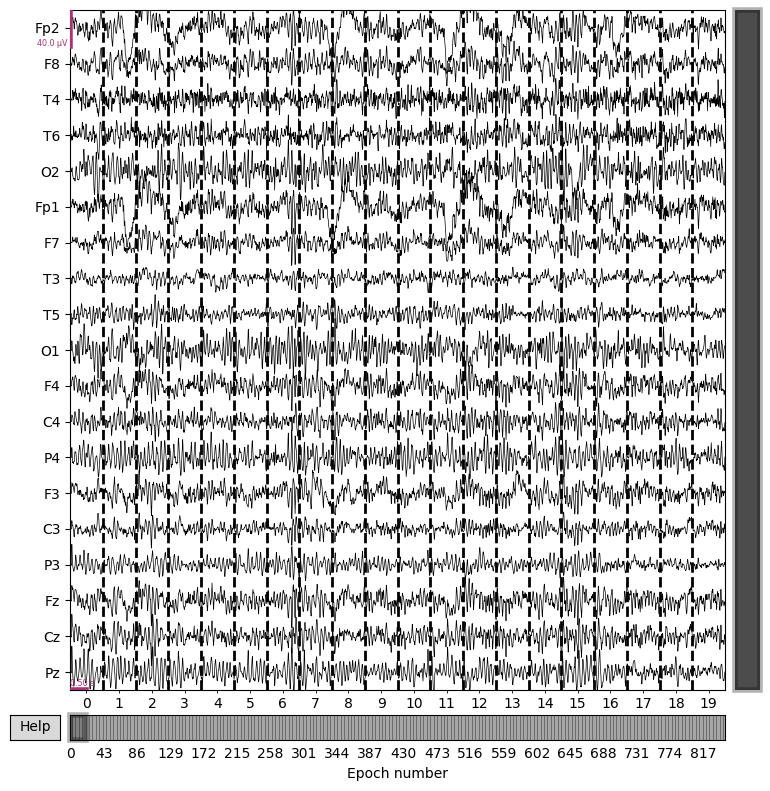

In [8]:
epochs.plot()

In [9]:
epochs.info

<Info | 8 non-empty values
 bads: []
 ch_names: Fp2, F8, T4, T6, O2, Fp1, F7, T3, T5, O1, F4, C4, P4, F3, C3, ...
 chs: 19 EEG
 custom_ref_applied: False
 highpass: 0.5 Hz
 lowpass: 40.0 Hz
 meas_date: 2004-08-20 12:19:24 UTC
 nchan: 19
 projs: []
 sfreq: 250.0 Hz
 subject_info: <subject_info | his_id: OJS>
>

In [10]:
import glob, os
import mne
import numpy as np

folder = r"D:\EEG DATA\dataverse_files"          # your folder
edf_paths = glob.glob(os.path.join(folder, "*.edf"))

X_list = []
y_list = []

for path in edf_paths:
    fname = os.path.basename(path).lower()

    # 1 = seizure, 0 = healthy  (edit these rules to match your filenames)
    if "s" in fname or "sz" in fname:
        label = 1
    elif "h" in fname or "nonseizure" in fname or "nsz" in fname:
        label = 0
    else:
        continue  # skip files you cannot classify

    raw = mne.io.read_raw_edf(path, preload=True)
    raw.filter(0.5, 40.)

    from mne import make_fixed_length_epochs
    epochs = make_fixed_length_epochs(raw, duration=1.0, overlap=0.0, preload=True)

    X = epochs.get_data()              # (n_epochs, n_ch, n_times)
    y = np.full(len(epochs), label)    # same label for all epochs of this file

    X_list.append(X)
    y_list.append(y)

# concatenate all files
X_all = np.concatenate(X_list, axis=0)
y_all = np.concatenate(y_list, axis=0)


Extracting EDF parameters from D:\EEG DATA\dataverse_files\h01.edf...
EDF file detected
Setting channel info structure...
Creating raw.info structure...
Reading 0 ... 231249  =      0.000 ...   924.996 secs...
Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 0.5 - 40 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 0.50
- Lower transition bandwidth: 0.50 Hz (-6 dB cutoff frequency: 0.25 Hz)
- Upper passband edge: 40.00 Hz
- Upper transition bandwidth: 10.00 Hz (-6 dB cutoff frequency: 45.00 Hz)
- Filter length: 1651 samples (6.604 s)

Not setting metadata
925 matching events found
No baseline correction applied
0 projection items activated
Using data from preloaded Raw for 925 events and 250 original time points ...
0 bad epochs dropped
Extracting EDF param

In [11]:
X_all.shape

(28863, 19, 250)

In [12]:
import numpy as np

X_1 = X_all.astype(np.float32)
chunk = 1000
for i in range(0, X_1.shape[0], chunk):
    sl = slice(i, i+chunk)
    mean = X_1[sl].mean(axis=-1, keepdims=True)
    std  = X_1[sl].std(axis=-1, keepdims=True) + 1e-8
    X_1[sl] = (X_1[sl] - mean) / std      # in-place scaling


In [13]:
X_1.shape

(28863, 19, 250)

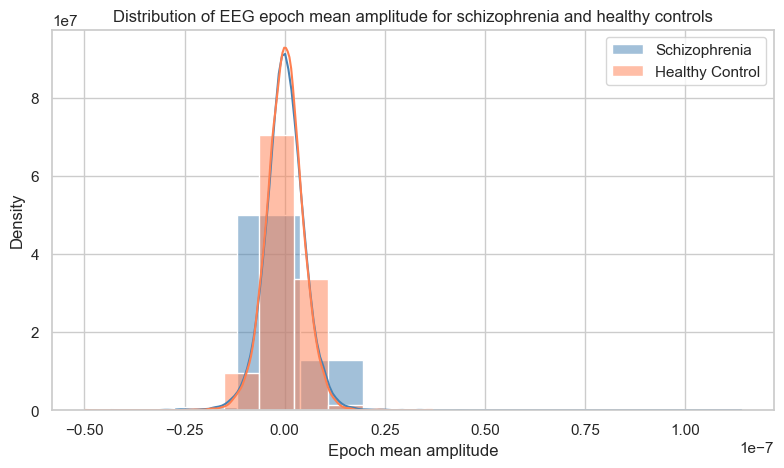

In [14]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sns.set(style="whitegrid")

# 1) compute mean per epoch (global mean over channels & time)
epoch_means = X_1.mean(axis=(1, 2))      # shape: (n_epochs,)

# 2) split by class
means_scz = epoch_means[y_all == 1]
means_hc  = epoch_means[y_all == 0]

# 3) plot distributions
plt.figure(figsize=(8,5))
sns.histplot(means_scz, color="steelblue", kde=True, stat="density",
             label="Schizophrenia", alpha=0.5, bins=10)
sns.histplot(means_hc,  color="coral",    kde=True, stat="density",
             label="Healthy Control", alpha=0.5, bins=10)

plt.xlabel("Epoch mean amplitude")
plt.ylabel("Density")
plt.title("Distribution of EEG epoch mean amplitude for schizophrenia and healthy controls")
plt.legend()
plt.tight_layout()
plt.show()


In [15]:
import numpy as np
from scipy.signal import spectrogram

def segment_to_tf_image(seg, fs=250):
    """
    seg : np.ndarray, shape (n_channels, n_times)
    returns : np.ndarray, shape (n_channels, n_freqs, n_time_windows)
    """
    imgs = []
    for ch in range(seg.shape[0]):
        f, t, Sxx = spectrogram(seg[ch], fs=fs, nperseg=64, noverlap=32)
        # Keep only 0-40 Hz
        idx = f <= 40                    # boolean mask
        f = f[idx]                       # new frequency vector
        Sxx = Sxx[idx, :]
        imgs.append(Sxx)                 # (n_freqs, n_time_windows)
    imgs = np.stack(imgs, axis=0)        # (n_channels, n_freqs, n_time_windows)
    return imgs


In [16]:
f, t, Sxx = spectrogram(X_1[0], fs=250, nperseg=64, noverlap=32)
# t is in seconds, length = 6 in your case

print(t)
print(f)


[0.128 0.256 0.384 0.512 0.64  0.768]
[  0.        3.90625   7.8125   11.71875  15.625    19.53125  23.4375
  27.34375  31.25     35.15625  39.0625   42.96875  46.875    50.78125
  54.6875   58.59375  62.5      66.40625  70.3125   74.21875  78.125
  82.03125  85.9375   89.84375  93.75     97.65625 101.5625  105.46875
 109.375   113.28125 117.1875  121.09375 125.     ]


In [17]:
imgs = []
for i in range(len(X_1)):
    seg = X_1[i]
    img = segment_to_tf_image(seg, fs=250)     # (19, f, t)
    imgs.append(np.expand_dims(img, -1))       # (19, f, t, 1)

X_img = np.stack(imgs, axis=0)                 # (N, 19, f, t, 1)

In [18]:
X_img.shape

(28863, 19, 11, 6, 1)

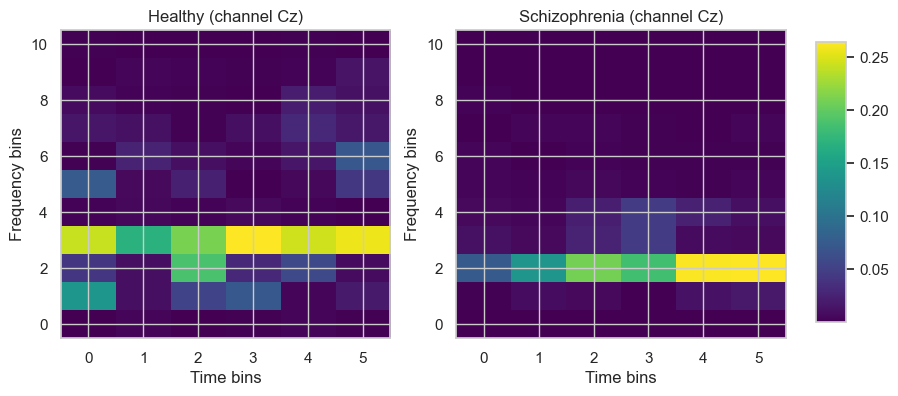

In [19]:
import numpy as np
import matplotlib.pyplot as plt

# indices of a healthy and a schizophrenia epoch
idx_hc  = np.where(y_all == 0)[0][0]
idx_scz = np.where(y_all == 1)[0][0]

# pick one channel, e.g. Cz (replace with its index, say 12)
ch_idx = 12

spec_hc  = X_img[idx_hc,  ch_idx, :, :, 0]   # (F, T)
spec_scz = X_img[idx_scz, ch_idx, :, :, 0]   # (F, T)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

im0 = axes[0].imshow(spec_hc, aspect='auto', origin='lower',
                     cmap='viridis')
axes[0].set_title('Healthy (channel Cz)')
axes[0].set_xlabel('Time bins')
axes[0].set_ylabel('Frequency bins')

im1 = axes[1].imshow(spec_scz, aspect='auto', origin='lower',
                     cmap='viridis')
axes[1].set_title('Schizophrenia (channel Cz)')
axes[1].set_xlabel('Time bins')
axes[1].set_ylabel('Frequency bins')

# move subplots a bit left so colorbar fits
plt.subplots_adjust(right=0.85)

# make colorbar in remaining 15% on the right
cbar_ax = fig.add_axes([0.88, 0.15, 0.03, 0.7])
fig.colorbar(im1, cax=cbar_ax)

plt.show()


In [20]:
import numpy as np

X = X_img          # shape (N, ...)
y = y_all          # shape (N,)
N = len(y)

rng = np.random.default_rng(seed=42)

train_idx = []
val_idx   = []
test_idx  = []

for cls in np.unique(y):
    cls_idx = np.where(y == cls)[0]
    rng.shuffle(cls_idx)

    n_cls   = len(cls_idx)
    n_train = int(0.70 * n_cls)
    n_val   = int(0.20 * n_cls)

    train_idx.extend(cls_idx[:n_train])
    val_idx.extend(cls_idx[n_train:n_train + n_val])
    test_idx.extend(cls_idx[n_train + n_val:])

train_idx = np.array(train_idx)
val_idx   = np.array(val_idx)
test_idx  = np.array(test_idx)

X_train, y_train = X[train_idx], y[train_idx]
X_val,   y_val   = X[val_idx],   y[val_idx]
X_test,  y_test  = X[test_idx],  y[test_idx]


In [21]:
print(X_train.shape, y_train.shape)  # training set
print(X_val.shape,   y_val.shape)     # validation set
print(X_test.shape,  y_test.shape)    # final test set

(20204, 19, 11, 6, 1) (20204,)
(5772, 19, 11, 6, 1) (5772,)
(2887, 19, 11, 6, 1) (2887,)


In [3]:
from PIL import Image

img = Image.open(r"D:\EEG DATA\images\Model Architecture.jpg")
img.save(r"D:\EEG DATA\images\Model-Architecture_60dpi.jpg", dpi=(60, 60))


In [22]:
import tensorflow as tf
from tensorflow.keras import layers, models, regularizers, Input

from tensorflow import keras
import tensorflow as tf
import numpy as np


inputs = Input(shape=(19, 11, 6, 1))      # (C,F,T,1)

x = layers.Conv3D(16, (3,3,3), padding='same', activation='relu')(inputs)
x = layers.BatchNormalization()(x)
x = layers.MaxPool3D((2,2,2), padding='same')(x)
print(x)

x = layers.Conv3D(32, (3,3,3), padding='same', activation='relu')(x)
x = layers.BatchNormalization()(x)
x = layers.MaxPool3D((2,2,2), padding='same')(x)
print(x)
x = layers.Conv3D(64, (3,3,3), padding='same', activation='relu')(x)
x = layers.BatchNormalization()(x)
x = layers.MaxPool3D((2,2,1), padding='same')(x)
print(x)
# Keras Lambda layer to pool over channels (axis=1) and time (axis=3)
x = layers.Lambda(lambda t: tf.reduce_mean(t, axis=[1,3]))(x)
# x: (batch, F', 64)

x = layers.Dense(16, activation='relu')(x)       # per-frequency features
x = layers.GlobalAveragePooling1D()(x)           # (batch, 32)

x = layers.Dense(16, activation='relu',
                 kernel_regularizer=regularizers.l2(1e-4))(x)
x = layers.Dropout(0.5)(x)
outputs = layers.Dense(2, activation='softmax')(x)




model = models.Model(inputs=inputs, outputs=outputs)
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])



history = model.fit(X_train, y_train,
          batch_size=32,
          epochs=30,
          validation_data=(X_val, y_val),
          shuffle=True)


<KerasTensor shape=(None, 10, 6, 3, 16), dtype=float32, sparse=False, ragged=False, name=keras_tensor_3>
<KerasTensor shape=(None, 5, 3, 2, 32), dtype=float32, sparse=False, ragged=False, name=keras_tensor_6>
<KerasTensor shape=(None, 3, 2, 2, 64), dtype=float32, sparse=False, ragged=False, name=keras_tensor_9>

Epoch 1/30
632/632 ━━━━━━━━━━━━━━━━━━━━ 22s 18ms/step - accuracy: 0.6788 - loss: 0.5919 - val_accuracy: 0.5191 - val_loss: 1.0806
Epoch 2/30
632/632 ━━━━━━━━━━━━━━━━━━━━ 19s 20ms/step - accuracy: 0.8205 - loss: 0.4089 - val_accuracy: 0.5288 - val_loss: 2.1079
Epoch 3/30
632/632 ━━━━━━━━━━━━━━━━━━━━ 13s 20ms/step - accuracy: 0.8654 - loss: 0.3247 - val_accuracy: 0.6753 - val_loss: 0.8286
Epoch 4/30
632/632 ━━━━━━━━━━━━━━━━━━━━ 14s 21ms/step - accuracy: 0.8952 - loss: 0.2643 - val_accuracy: 0.7058 - val_loss: 1.0223
Epoch 5/30
632/632 ━━━━━━━━━━━━━━━━━━━━ 20s 20ms/step - accuracy: 0.9076 - loss: 0.2336 - val_accuracy: 0.8165 - val_loss: 0.4573
Epoch 6/30
632/632 ━━━━━━━━━━━━━━━━━

In [67]:
model.evaluate(X_test, y_test)

91/91 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.8452 - loss: 0.8190


[0.8190224766731262, 0.8451679944992065]

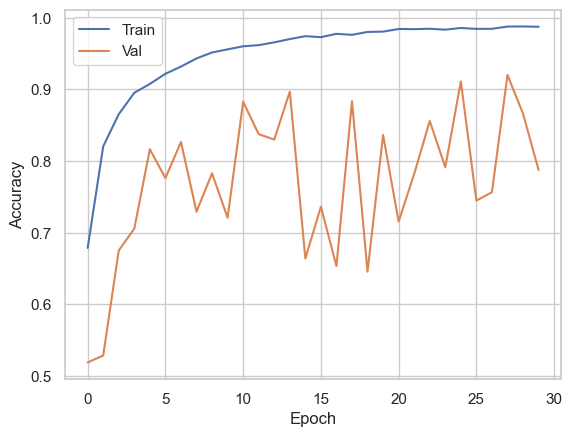

In [23]:
import matplotlib.pyplot as plt

# 1) Accuracy
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.xlabel('Epoch'); plt.ylabel('Accuracy')
plt.legend(['Train','Val']); plt.show()


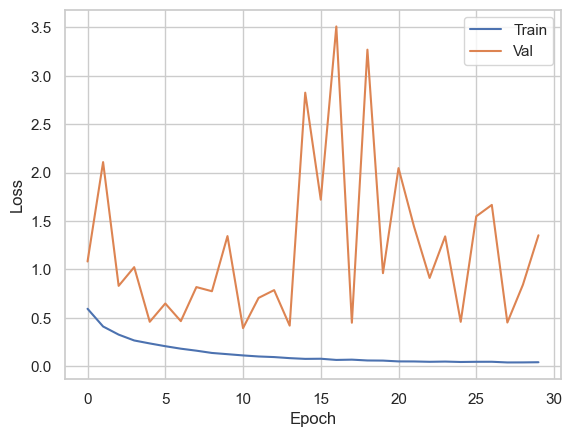

In [24]:
# 2) Loss
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.xlabel('Epoch'); plt.ylabel('Loss')
plt.legend(['Train','Val']); plt.show()

632/632 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step
91/91 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step


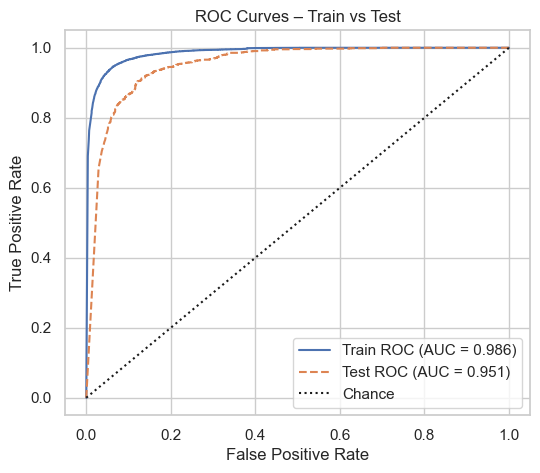

In [25]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# 1. Get probabilities
# If model outputs 2 probs: [p_class0, p_class1]
y_train_prob = model.predict(X_train)[:, 1]   # positive class only
y_test_prob  = model.predict(X_test)[:, 1]


# 2. Compute ROC points and AUC
fpr_tr, tpr_tr, _ = roc_curve(y_train, y_train_prob)
auc_tr = auc(fpr_tr, tpr_tr)

fpr_te, tpr_te, _ = roc_curve(y_test, y_test_prob)
auc_te = auc(fpr_te, tpr_te)

# 3. Plot
plt.figure(figsize=(6,5))
plt.plot(fpr_tr, tpr_tr, label=f'Train ROC (AUC = {auc_tr:.3f})')
plt.plot(fpr_te, tpr_te, label=f'Test ROC (AUC = {auc_te:.3f})', linestyle='--')
plt.plot([0,1], [0,1], 'k:', label='Chance')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves – Train vs Test')
plt.legend()
plt.grid(True)
plt.show()


In [34]:
model.save(r"D:\EEG DATA\eeg-spectrogram.h5")

In [40]:
y_test[2810:2811]

array([1])

In [29]:
imgs = np.expand_dims(X_test[:10], axis=0)
prob = model.predict(imgs[0])
prob

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step


array([[6.1115640e-01, 3.8884357e-01],
       [4.6849116e-03, 9.9531507e-01],
       [7.6065433e-01, 2.3934567e-01],
       [7.9177201e-01, 2.0822801e-01],
       [9.9999988e-01, 8.9308202e-08],
       [2.1625117e-05, 9.9997842e-01],
       [5.3319782e-01, 4.6680221e-01],
       [8.2494360e-01, 1.7505641e-01],
       [7.7674979e-01, 2.2325021e-01],
       [9.7015119e-01, 2.9848879e-02]], dtype=float32)

In [30]:
y_test.shape

(2887,)

In [31]:
# predicted class probabilities from softmax
y_prob_all = model.predict(X_test)          # shape (n_samples, 2)

# choose prob for class 1 (seizure)
y_prob = y_prob_all[:, 1]

# class predictions
y_pred = np.argmax(y_prob_all, axis=1)      # 0 or 1


91/91 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step


In [32]:
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    cohen_kappa_score, confusion_matrix, roc_auc_score
)

acc   = accuracy_score(y_test, y_pred)
prec  = precision_score(y_test, y_pred)
sens  = recall_score(y_test, y_pred)        # sensitivity = recall for positive class
cm    = confusion_matrix(y_test, y_pred)
tn, fp, fn, tp = cm.ravel()
spec  = tn / (tn + fp)                      # specificity
f1    = f1_score(y_test, y_pred)
kappa = cohen_kappa_score(y_test, y_pred)
auc   = roc_auc_score(y_test, y_prob)
err   = 1 - acc

print("Accuracy:", acc)
print("Error:", err)
print("Precision:", prec)
print("Sensitivity (Recall):", sens)
print("Specificity:", spec)
print("F1-score:", f1)
print("Kappa:", kappa)
print("AUC:", auc)
print("Confusion matrix:\n", cm)


Accuracy: 0.7966747488742639
Error: 0.20332525112573607
Precision: 0.731322505800464
Sensitivity (Recall): 0.9949494949494949
Specificity: 0.555640828856485
F1-score: 0.8430061513773737
Kappa: 0.5728571957878266
AUC: 0.9509198857337767
Confusion matrix:
 [[ 724  579]
 [   8 1576]]


In [60]:
import shap
import numpy as np

# 1) background for GradientExplainer (small subset of train)
background = X_train[np.random.choice(len(X_train), 100, replace=False)]

# 2) build explainer
explainer = shap.GradientExplainer(model, background)

# 3) get SHAP values for some test samples
X_sample = X_test[2810:2811]     # (100, 19, 33, 6, 1)
shap_values = explainer.shap_values(X_sample)  # list; for binary: len=1
sh = shap_values[0]         # (100, 19, 33, 6, 1) [100-epochs, 19-channels, 33-freq bin, 6-time bin, 1-channel of TF img that is power]


f:\Anaconda\envs\new_env\Lib\site-packages\keras\src\models\functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: keras_tensor
Received: inputs=['Tensor(shape=(1, 19, 11, 6, 1))']
  warnings.warn(msg)
f:\Anaconda\envs\new_env\Lib\site-packages\keras\src\models\functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: keras_tensor
Received: inputs=['Tensor(shape=(50, 19, 11, 6, 1))']
  warnings.warn(msg)


In [61]:
print(shap_values[0].shape)
print(sh.shape)

(19, 11, 6, 1, 2)
(19, 11, 6, 1, 2)


In [62]:
sh_sample = shap_values[0]             # (19, 33, 6, 1, 2)

# drop the image-channel dim
sh_sample = sh_sample[..., 0, :]       # (19, 33, 6, 2)

# separate classes
sh_class0 = sh_sample[..., 0]          # (19, 33, 6)
sh_class1 = sh_sample[..., 1]          # (19, 33, 6)

# average over channels to get freq×time
sh0_freq_time = sh_class0.mean(axis=0) # (33, 6)
sh1_freq_time = sh_class1.mean(axis=0) # (33, 6)
           # should be (33, 6)



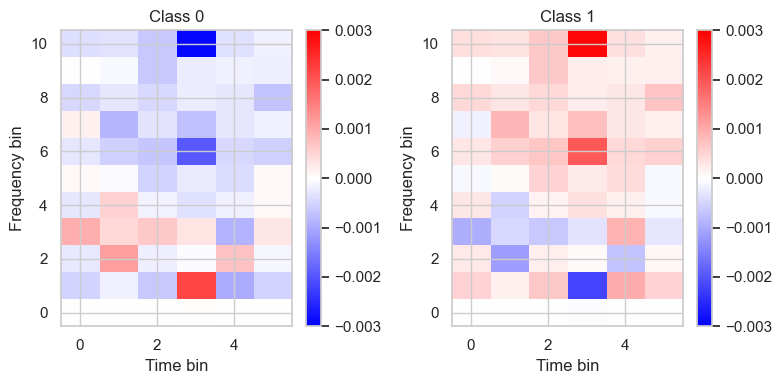

In [63]:
fig, axes = plt.subplots(1, 2, figsize=(8, 4))

im0 = axes[0].imshow(sh0_freq_time, aspect='auto', origin='lower',
                     cmap='bwr', vmin=-0.003, vmax=0.003)
axes[0].set_title('Class 0')
axes[0].set_ylabel('Frequency bin')
axes[0].set_xlabel('Time bin')
fig.colorbar(im0, ax=axes[0])

im1 = axes[1].imshow(sh1_freq_time, aspect='auto', origin='lower',
                     cmap='bwr', vmin=-0.003, vmax=0.003)
axes[1].set_title('Class 1')
axes[1].set_ylabel('Frequency bin')
axes[1].set_xlabel('Time bin')
fig.colorbar(im1, ax=axes[1])

plt.tight_layout()
plt.show()


In [48]:
# full SHAP for this batch
sh_full = shap_values[0]          # (19, 33, 6, 1, 2)

# drop image-channel
sh_full = sh_full[..., 0, :]      # (19, 33, 6, 2)

# separate classes
sh_class0 = sh_full[..., 0]       # (19, 33, 6)
sh_class1 = sh_full[..., 1]       # (19, 33, 6)

# average over time -> (19, 33)
sh0_ch_freq = sh_class0.mean(axis=-1)
sh1_ch_freq = sh_class1.mean(axis=-1)

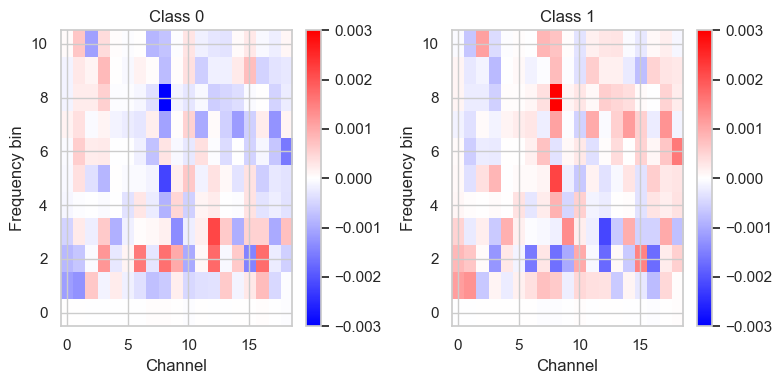

In [64]:
# plot both together
fig, axes = plt.subplots(1, 2, figsize=(8, 4))

im0 = axes[0].imshow(sh0_ch_freq.T, aspect='auto', origin='lower',
                     cmap='bwr', vmin=-0.003, vmax=0.003)
axes[0].set_title('Class 0')
axes[0].set_xlabel('Channel')
axes[0].set_ylabel('Frequency bin')
fig.colorbar(im0, ax=axes[0])

im1 = axes[1].imshow(sh1_ch_freq.T, aspect='auto', origin='lower',
                     cmap='bwr', vmin=-0.003, vmax=0.003)
axes[1].set_title('Class 1')
axes[1].set_xlabel('Channel')
axes[1].set_ylabel('Frequency bin')
fig.colorbar(im1, ax=axes[1])

plt.tight_layout()
plt.show()

In [65]:
i = 2810
X_i = X_test[i:i+1]  # (1, 19, 33, 6, 1)

shap_values = explainer.shap_values(X_i, nsamples=200)  # (1, 19, 33, 6, 1, 2)

# remove batch dim -> (19, 33, 6, 1, 2)
sh_i = shap_values[0]

# drop image-channel dim -> (19, 33, 6, 2)
sh_i = sh_i[..., 0, :]

# split by class
sh_i_class0 = sh_i[..., 0]   # (19, 33, 6) for class 0
sh_i_class1 = sh_i[..., 1]   # (19, 33, 6) for class 1

# background: (B, 19, 33, 6, 1)
probs_bg = model.predict(background, batch_size=32)[:, 1]   # class 1 probs, shape (B,)
phi0 = probs_bg.mean()

# sh_i_class1: SHAP for class 1, shape (19, 33, 6)
phi_sum = sh_i_class1.sum()
approx_prob = phi0 + phi_sum

print("phi0 (mean prob, class 1):", phi0)
print("sum of SHAPs (class 1):", phi_sum)
print("phi0 + sum:", approx_prob)

probs_i = model.predict(X_i)[0]     # shape (2,)
prob_i_class1 = float(probs_i[1])   # class 1
print("model prob for sample i, class 1:", prob_i_class1)


4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step
phi0 (mean prob, class 1): 0.73922265
sum of SHAPs (class 1): 0.3670231780148754
phi0 + sum: 1.106245823774458
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
model prob for sample i, class 1: 1.0


In [66]:
# background: (B, 19, 33, 6, 1)
probs_bg = model.predict(background, batch_size=32)[:, 0]  # class 0 probs
phi0 = probs_bg.mean()                                    # baseline for class 0

# sh_i_class0: SHAP for class 0, shape (19, 33, 6)
phi_sum = sh_i_class0.sum()
approx_prob = phi0 + phi_sum

print("phi0 (mean prob, class 0):", phi0)
print("sum of SHAPs (class 0):", phi_sum)
print("phi0 + sum:", approx_prob)

probs_i = model.predict(X_i)[0]     # shape (2,)
prob_i_class0 = float(probs_i[0])   # class 0 prob
print("model prob for sample i, class 0:", prob_i_class0)


4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
phi0 (mean prob, class 0): 0.2607773
sum of SHAPs (class 0): -0.36702320831651036
phi0 + sum: -0.10624591368073766
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
model prob for sample i, class 0: 5.996855095835585e-11


#### GradCAM Analysis ####

In [67]:
for layer in model.layers:
    print(layer.name, layer.output.shape)


input_layer (None, 19, 11, 6, 1)
conv3d (None, 19, 11, 6, 16)
batch_normalization (None, 19, 11, 6, 16)
max_pooling3d (None, 10, 6, 3, 16)
conv3d_1 (None, 10, 6, 3, 32)
batch_normalization_1 (None, 10, 6, 3, 32)
max_pooling3d_1 (None, 5, 3, 2, 32)
conv3d_2 (None, 5, 3, 2, 64)
batch_normalization_2 (None, 5, 3, 2, 64)
max_pooling3d_2 (None, 3, 2, 2, 64)
lambda (None, 2, 64)
dense (None, 2, 16)
global_average_pooling1d (None, 16)
dense_1 (None, 16)
dropout (None, 16)
dense_2 (None, 2)


In [69]:
# after you define `model`
layer_names = [l.name for l in model.layers]

# choose layers you want to inspect
inspect_layers = ['conv3d_2']  # example names

outputs = [model.get_layer(n).output for n in inspect_layers]
debug_model = keras.Model(inputs=model.input, outputs=outputs)

# run a batch through
feat_maps = debug_model(X_train[:1])   # list of activations

print(feat_maps.shape)
print(feat_maps)


(1, 5, 3, 2, 64)
tf.Tensor(
[[[[[0.         0.         5.7516828  ... 0.         0.
     0.        ]
    [0.         0.         9.020456   ... 0.         0.
     2.8757262 ]]

   [[0.         1.5650449  0.         ... 0.         0.
     0.        ]
    [0.         0.         3.7516632  ... 0.         0.
     0.        ]]

   [[0.         0.         0.         ... 0.         0.
     0.        ]
    [0.         0.         0.         ... 0.         0.
     0.        ]]]


  [[[0.         0.         0.         ... 0.         0.
     0.        ]
    [0.         0.         1.0508466  ... 0.         0.
     0.        ]]

   [[6.5244255  0.8446976  0.         ... 0.         0.
     0.        ]
    [7.510296   0.         0.         ... 0.         0.
     0.        ]]

   [[0.         0.         0.         ... 0.         0.
     0.1674949 ]
    [0.         0.         0.         ... 0.         0.
     0.        ]]]


  [[[0.         0.         0.         ... 0.         0.
     0.        ]
    [0.

In [71]:
import tensorflow as tf
import numpy as np

last_conv_layer_name = "conv3d_2"  # or whatever name you printed
last_output_layer = "dense_2"

grad_model = tf.keras.models.Model(
    inputs=model.inputs,
    outputs=[model.get_layer(last_conv_layer_name).output,
             model.get_layer(last_output_layer).output]
)

In [77]:
def make_gradcam3_heatmap(input_sample, class_index=None):
    """
    input_sample: single EEG TF volume, shape (19, 11, 6, 1)
    class_index: 0 or 1 (if None, uses model's predicted class)
    returns: Grad-CAM heatmap, shape (11, 6) after channel-averaging
    """
    # add batch dimension
    x = tf.cast(input_sample[None, ...], tf.float32)

    with tf.GradientTape() as tape:
        conv_outputs, preds = grad_model(x)
        if class_index is None:
            class_index = int(class_index)
            class_index = tf.argmax(preds[0])
        class_channel = preds[:, class_index]

    # gradient of score wrt conv feature maps
    grads = tape.gradient(class_channel, conv_outputs)              # (1, D, H, W, C)
    pooled_grads = tf.reduce_mean(grads, axis=(1, 2, 3))            # (1, C)

    # weight the feature maps
    conv_outputs = conv_outputs[0]                                  # (D, H, W, C)
    pooled_grads = pooled_grads[0]

    weighted = conv_outputs * pooled_grads                          # broadcast (D,H,W,C)
    cam_3d = tf.reduce_mean(weighted, axis=-1)                      # (D, H, W)

    # ReLU
    cam_3d = tf.nn.relu(cam_3d)
    return cam_3d

In [78]:
# pick an index of a correctly predicted seizure sample
idx = 2810   # for example
x_seizure = X_test[idx]
y_true    = y_test[idx]

# 1) get Grad-CAM maps for seizure class (1)
cam_3d = make_gradcam3_heatmap(x_seizure, class_index=1)  
# cam_ft: (11, 6)  freq × time
# cam_cf: (19, 11) channel × freq


In [79]:
# cam_3d: (D, F, T) = (5, 3, 2)

# 1) freq × time  (average over channels)
cam_ft = tf.reduce_mean(cam_3d, axis=0)      # (F, T) = (3, 2)

# 2) channel × freq  (average over time)
cam_cf = tf.reduce_mean(cam_3d, axis=2)      # (D, F) = (5, 3)

# 3) freq × channel  (transpose of channel × freq)
cam_fc = tf.transpose(cam_cf, perm=[1, 0])   # (F, D) = (3, 5)

# 4) channel × time  (average over freq)
cam_ct = tf.reduce_mean(cam_3d, axis=1)      # (D, T) = (5, 2)


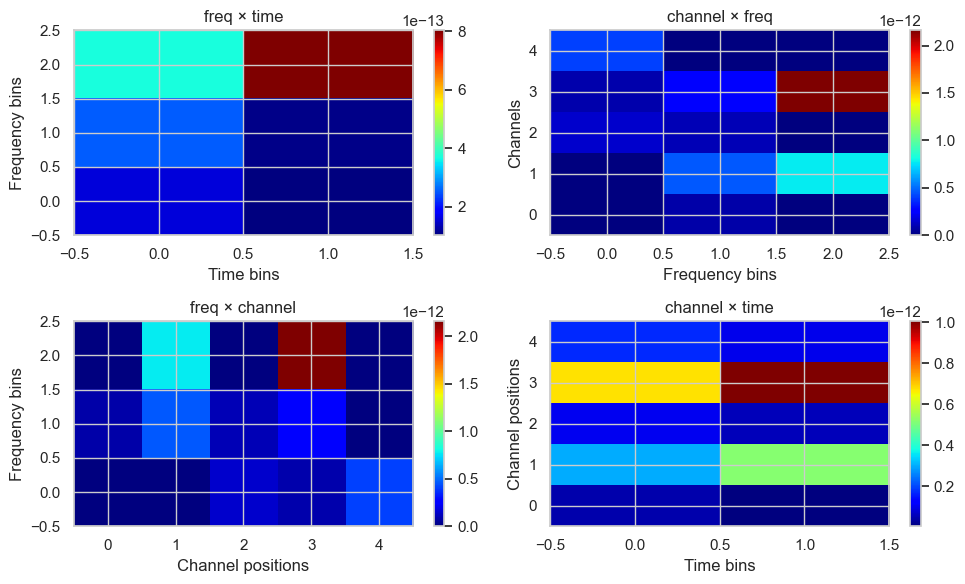

In [80]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 2, figsize=(10, 6))

# (0,0) Frequency × Time
im0 = axes[0,0].imshow(cam_ft, origin='lower', aspect='auto', cmap='jet')
axes[0,0].set_title('freq × time')
axes[0,0].set_xlabel('Time bins')
axes[0,0].set_ylabel('Frequency bins')
fig.colorbar(im0, ax=axes[0,0])

# (0,1) Channel × Frequency
im1 = axes[0,1].imshow(cam_cf, origin='lower', aspect='auto', cmap='jet')
axes[0,1].set_title('channel × freq')
axes[0,1].set_xlabel('Frequency bins')
axes[0,1].set_ylabel('Channels')
fig.colorbar(im1, ax=axes[0,1])

# (1,0) Frequency × Channel
im2 = axes[1,0].imshow(cam_fc, origin='lower', aspect='auto', cmap='jet')
axes[1,0].set_title('freq × channel')
axes[1,0].set_xlabel('Channel positions')
axes[1,0].set_ylabel('Frequency bins')
fig.colorbar(im2, ax=axes[1,0])

# (1,1) Channel × Time
im3 = axes[1,1].imshow(cam_ct, origin='lower', aspect='auto', cmap='jet')
axes[1,1].set_title('channel × time')
axes[1,1].set_xlabel('Time bins')
axes[1,1].set_ylabel('Channel positions')
fig.colorbar(im3, ax=axes[1,1])

plt.tight_layout()
plt.show()


In [81]:
from tensorflow.keras import layers, models, regularizers
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

inputs = layers.Input(shape=(19, 11, 6, 1))

x = layers.Conv3D(16, (3,3,3), padding='same', activation='relu',
                  kernel_regularizer=regularizers.l2(1e-4))(inputs)
x = layers.BatchNormalization()(x)
x = layers.MaxPool3D((2,2,2), padding='same')(x)
x = layers.Dropout(0.2)(x)      # mild dropout in early block

x = layers.Conv3D(32, (3,3,3), padding='same', activation='relu',
                  kernel_regularizer=regularizers.l2(1e-4))(x)
x = layers.BatchNormalization()(x)
x = layers.MaxPool3D((2,2,2), padding='same')(x)
x = layers.Dropout(0.3)(x)      # stronger deeper

x = layers.Conv3D(64, (3,3,3), padding='same', activation='relu',
                  kernel_regularizer=regularizers.l2(1e-4))(x)
x = layers.BatchNormalization()(x)
x = layers.MaxPool3D((2,2,1), padding='same')(x)
x = layers.Dropout(0.4)(x)

x = layers.Flatten()(x)
x = layers.Dense(128, activation='relu',
                 kernel_regularizer=regularizers.l2(1e-4))(x)
x = layers.Dropout(0.5)(x)
outputs = layers.Dense(2, activation='softmax')(x)

model1 = models.Model(inputs=inputs, outputs=outputs)
model1.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

# early stopping + best‑model checkpoint
es = EarlyStopping(
    monitor='val_loss',
    mode='min',
    patience=5,              # adjust after looking at curves
    restore_best_weights=True,
    verbose=1
)

mc = ModelCheckpoint(
    'best_eeg_model.h5',
    monitor='val_loss',
    mode='min',
    save_best_only=True,
    verbose=1
)

history = model1.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=50,
    batch_size=32,
    callbacks=[es, mc],
    shuffle=True
)


Epoch 1/50
631/632 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.5670 - loss: 0.7949
Epoch 1: val_loss improved from None to 1.36190, saving model to best_eeg_model.h5


632/632 ━━━━━━━━━━━━━━━━━━━━ 18s 23ms/step - accuracy: 0.6115 - loss: 0.7002 - val_accuracy: 0.5606 - val_loss: 1.3619
Epoch 2/50
631/632 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.7018 - loss: 0.6021
Epoch 2: val_loss improved from 1.36190 to 0.56737, saving model to best_eeg_model.h5


632/632 ━━━━━━━━━━━━━━━━━━━━ 15s 23ms/step - accuracy: 0.7239 - loss: 0.5745 - val_accuracy: 0.7230 - val_loss: 0.5674
Epoch 3/50
631/632 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.7783 - loss: 0.5072
Epoch 3: val_loss improved from 0.56737 to 0.55070, saving model to best_eeg_model.h5


632/632 ━━━━━━━━━━━━━━━━━━━━ 15s 23ms/step - accuracy: 0.7892 - loss: 0.4895 - val_accuracy: 0.7455 - val_loss: 0.5507
Epoch 4/50
630/632 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.8181 - loss: 0.4406
Epoch 4: val_loss improved from 0.55070 to 0.48717, saving model to best_eeg_model.h5


632/632 ━━━━━━━━━━━━━━━━━━━━ 20s 23ms/step - accuracy: 0.8221 - loss: 0.4326 - val_accuracy: 0.7767 - val_loss: 0.4872
Epoch 5/50
632/632 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.8366 - loss: 0.4034
Epoch 5: val_loss improved from 0.48717 to 0.38463, saving model to best_eeg_model.h5


...

632/632 ━━━━━━━━━━━━━━━━━━━━ 21s 24ms/step - accuracy: 0.8740 - loss: 0.3417 - val_accuracy: 0.8704 - val_loss: 0.3588
Epoch 8/50
629/632 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.8843 - loss: 0.3301
Epoch 8: val_loss did not improve from 0.35876
632/632 ━━━━━━━━━━━━━━━━━━━━ 14s 22ms/step - accuracy: 0.8858 - loss: 0.3214 - val_accuracy: 0.8174 - val_loss: 0.4606
Epoch 9/50
631/632 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.8885 - loss: 0.3165
Epoch 9: val_loss did not improve from 0.35876
632/632 ━━━━━━━━━━━━━━━━━━━━ 16s 26ms/step - accuracy: 0.8910 - loss: 0.3132 - val_accuracy: 0.7952 - val_loss: 0.5665
Epoch 10/50
630/632 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.8999 - loss: 0.3076
Epoch 10: val_loss did not improve from 0.35876
632/632 ━━━━━━━━━━━━━━━━━━━━ 18s 22ms/step - accuracy: 0.9020 - loss: 0.3011 - val_accuracy: 0.7926 - val_loss: 0.5249
Epoch 11/50
629/632 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.9031 - loss: 0.2867
Epoch 11: val_loss did not impro

632/632 ━━━━━━━━━━━━━━━━━━━━ 13s 21ms/step - accuracy: 0.9141 - loss: 0.2780 - val_accuracy: 0.9139 - val_loss: 0.2769
Epoch 13/50
629/632 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.9120 - loss: 0.2754
Epoch 13: val_loss did not improve from 0.27687
632/632 ━━━━━━━━━━━━━━━━━━━━ 13s 21ms/step - accuracy: 0.9137 - loss: 0.2741 - val_accuracy: 0.7249 - val_loss: 0.8803
Epoch 14/50
629/632 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.9110 - loss: 0.2836
Epoch 14: val_loss improved from 0.27687 to 0.23288, saving model to best_eeg_model.h5


632/632 ━━━━━━━━━━━━━━━━━━━━ 13s 20ms/step - accuracy: 0.9144 - loss: 0.2736 - val_accuracy: 0.9321 - val_loss: 0.2329
Epoch 15/50
629/632 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.9183 - loss: 0.2692
Epoch 15: val_loss did not improve from 0.23288
632/632 ━━━━━━━━━━━━━━━━━━━━ 13s 20ms/step - accuracy: 0.9187 - loss: 0.2652 - val_accuracy: 0.7382 - val_loss: 0.8153
Epoch 16/50
629/632 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.9148 - loss: 0.2666
Epoch 16: val_loss did not improve from 0.23288
632/632 ━━━━━━━━━━━━━━━━━━━━ 13s 21ms/step - accuracy: 0.9174 - loss: 0.2637 - val_accuracy: 0.7883 - val_loss: 0.6347
Epoch 17/50
632/632 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.9231 - loss: 0.2599
Epoch 17: val_loss did not improve from 0.23288
632/632 ━━━━━━━━━━━━━━━━━━━━ 14s 22ms/step - accuracy: 0.9264 - loss: 0.2552 - val_accuracy: 0.8222 - val_loss: 0.5524
Epoch 18/50
631/632 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.9224 - loss: 0.2578
Epoch 18: val_loss improved 

632/632 ━━━━━━━━━━━━━━━━━━━━ 19s 19ms/step - accuracy: 0.9254 - loss: 0.2537 - val_accuracy: 0.9399 - val_loss: 0.2304
Epoch 19/50
631/632 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.9275 - loss: 0.2543
Epoch 19: val_loss did not improve from 0.23041
632/632 ━━━━━━━━━━━━━━━━━━━━ 13s 21ms/step - accuracy: 0.9295 - loss: 0.2523 - val_accuracy: 0.7711 - val_loss: 0.6855
Epoch 20/50
630/632 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.9340 - loss: 0.2507
Epoch 20: val_loss did not improve from 0.23041
632/632 ━━━━━━━━━━━━━━━━━━━━ 19s 19ms/step - accuracy: 0.9338 - loss: 0.2472 - val_accuracy: 0.7763 - val_loss: 0.6777
Epoch 21/50
630/632 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.9308 - loss: 0.2464
Epoch 21: val_loss did not improve from 0.23041
632/632 ━━━━━━━━━━━━━━━━━━━━ 15s 23ms/step - accuracy: 0.9328 - loss: 0.2416 - val_accuracy: 0.8361 - val_loss: 0.5686
Epoch 22/50
632/632 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.9301 - loss: 0.2455
Epoch 22: val_loss improved 

632/632 ━━━━━━━━━━━━━━━━━━━━ 19s 20ms/step - accuracy: 0.9326 - loss: 0.2420 - val_accuracy: 0.9449 - val_loss: 0.2303
Epoch 23/50
630/632 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.9334 - loss: 0.2485
Epoch 23: val_loss did not improve from 0.23035
632/632 ━━━━━━━━━━━━━━━━━━━━ 15s 24ms/step - accuracy: 0.9355 - loss: 0.2416 - val_accuracy: 0.8770 - val_loss: 0.3924
Epoch 24/50
630/632 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.9356 - loss: 0.2402
Epoch 24: val_loss did not improve from 0.23035
632/632 ━━━━━━━━━━━━━━━━━━━━ 14s 22ms/step - accuracy: 0.9369 - loss: 0.2359 - val_accuracy: 0.7249 - val_loss: 1.0042
Epoch 25/50
631/632 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.9334 - loss: 0.2420
Epoch 25: val_loss did not improve from 0.23035
632/632 ━━━━━━━━━━━━━━━━━━━━ 19s 20ms/step - accuracy: 0.9361 - loss: 0.2378 - val_accuracy: 0.8262 - val_loss: 0.5795
Epoch 26/50
632/632 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.9411 - loss: 0.2353
Epoch 26: val_loss did not i

In [82]:
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    cohen_kappa_score, confusion_matrix, roc_auc_score
)

acc   = accuracy_score(y_test, y_pred)
prec  = precision_score(y_test, y_pred)
sens  = recall_score(y_test, y_pred)        # sensitivity = recall for positive class
cm    = confusion_matrix(y_test, y_pred)
tn, fp, fn, tp = cm.ravel()
spec  = tn / (tn + fp)                      # specificity
f1    = f1_score(y_test, y_pred)
kappa = cohen_kappa_score(y_test, y_pred)
auc   = roc_auc_score(y_test, y_prob)
err   = 1 - acc

print("Accuracy:", acc)
print("Error:", err)
print("Precision:", prec)
print("Sensitivity (Recall):", sens)
print("Specificity:", spec)
print("F1-score:", f1)
print("Kappa:", kappa)
print("AUC:", auc)
print("Confusion matrix:\n", cm)


Accuracy: 0.7966747488742639
Error: 0.20332525112573607
Precision: 0.731322505800464
Sensitivity (Recall): 0.9949494949494949
Specificity: 0.555640828856485
F1-score: 0.8430061513773737
Kappa: 0.5728571957878266
AUC: 0.9509198857337767
Confusion matrix:
 [[ 724  579]
 [   8 1576]]


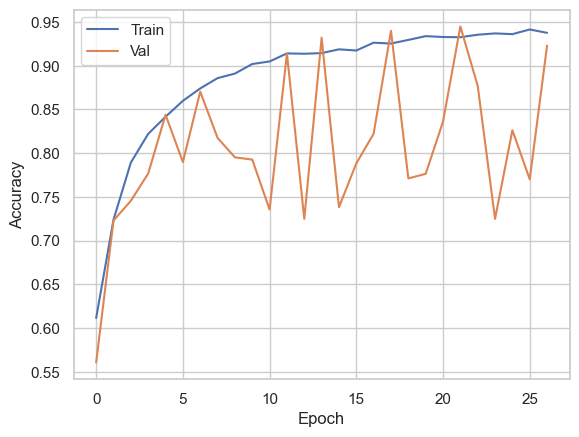

In [83]:
import matplotlib.pyplot as plt

# 1) Accuracy
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.xlabel('Epoch'); plt.ylabel('Accuracy')
plt.legend(['Train','Val']); plt.show()


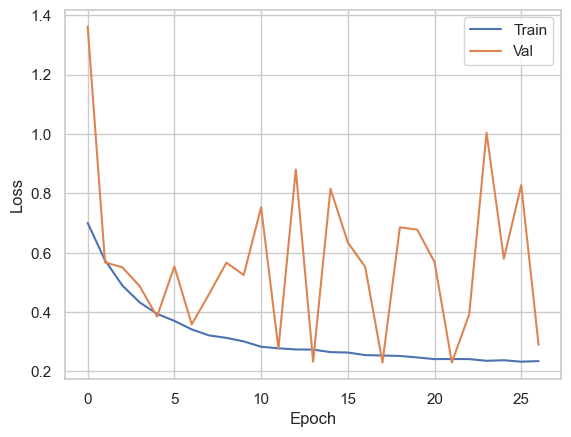

In [84]:
# 2) Loss
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.xlabel('Epoch'); plt.ylabel('Loss')
plt.legend(['Train','Val']); plt.show()